# Sunspot Time-Series Forecasting with MLP and GRU

**1. Data Loading and Initial Inspection**

In [1]:
from pathlib import Path
import pandas as pd

sunspots_path = Path("data/sunspots.csv")

sunspots = pd.read_csv(sunspots_path)

In [2]:
sunspots.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7


In [3]:
sunspots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3252 entries, 0 to 3251
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         3252 non-null   int64  
 1   Date                               3252 non-null   object 
 2   Monthly Mean Total Sunspot Number  3252 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 76.3+ KB


In [4]:
sunspots.columns

Index(['Unnamed: 0', 'Date', 'Monthly Mean Total Sunspot Number'], dtype='object')

The column we are interested in for our analysis is "Monthly Mean Total Sunspot Number"

In [5]:
sunspot = sunspots["Monthly Mean Total Sunspot Number"]

**2. Data Quality Check and Exploratory Analysis**

In [6]:
#Checking for missing values
print(sunspot.isnull().sum())

0


Therefore we don't have missing values in our dataset.
(zero values make sense in our dataset)

In [7]:
sunspot.describe()

count    3252.000000
mean       82.070695
std        67.864736
min         0.000000
25%        24.200000
50%        67.750000
75%       122.700000
max       398.200000
Name: Monthly Mean Total Sunspot Number, dtype: float64

In [8]:
import numpy as np

#Transport our data to a numpy array
sunspot_array = np.array(sunspot)

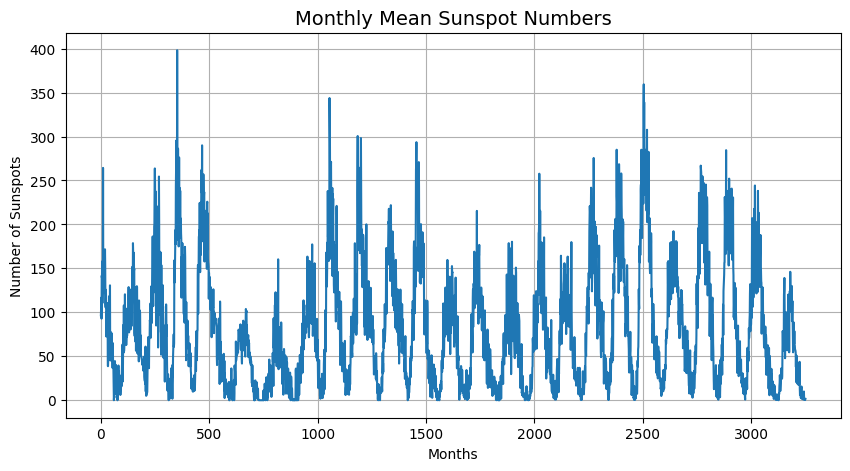

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(sunspot_array)

plt.xlabel("Months", fontsize=10)
plt.ylabel("Number of Sunspots", fontsize=10)

plt.title("Monthly Mean Sunspot Numbers", fontsize=14)
plt.grid()
plt.show()

**3. Data Scaling and Sequence Preparation**

We will scale our data in the range of [0, 1] using the "MinMaxScaler" for feature scaling

In [10]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
sunspots_scaled = min_max_scaler.fit_transform(sunspot_array.reshape(-1, 1)).flatten()

In [11]:
window_size = 40

test_size = int(len(sunspots_scaled) * 0.1)
#If we take 90% of the dataset for training we lose one sample. 
#Therefore we set train_size as the total length of our dataset minus the test size
train_size = len(sunspots_scaled) - test_size

train = sunspots_scaled[:train_size] #train set
test = sunspots_scaled[train_size - window_size:] #test set

forecast_horizon = test_size

In [12]:
import numpy as np

def create_dataset(dataset, look_back=1, horizon=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back - horizon + 1):
        dataX.append(dataset[i : i + look_back])
        dataY.append(dataset[i + look_back : i + look_back + horizon])
    return np.array(dataX), np.array(dataY)

X_train, y_train = create_dataset(train, window_size, forecast_horizon)  
X_test, y_test = create_dataset(test, window_size, forecast_horizon)

print("Χ_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("Χ_test:", X_test.shape)
print("y_test:", y_test.shape)

Χ_train:  (2563, 40)
y_train:  (2563, 325)
Χ_test: (1, 40)
y_test: (1, 325)


**4. MLP Model Development and Training**

In [13]:
import tensorflow as tf

#clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_size,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(50, activation='selu', 
                          kernel_initializer='lecun_normal'),
    tf.keras.layers.Dense(25, activation='selu', 
                          kernel_initializer='lecun_normal'),
    tf.keras.layers.Dense(forecast_horizon)
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 40)             │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         2,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 325)            │         8,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,935 (46.62 KB)

 Trainable params: 11,855 (46.31 KB)

 Non-trainable params: 80 (320.00 B)

In [16]:
model.compile(loss="mse", optimizer=tf.keras.optimizers.AdamW(),
              metrics=["mae"])

In [17]:
import time

early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                  patience=2, 
                                                  restore_best_weights=True)

start_time = time.time()

history_early_stopping = model.fit(X_train, y_train,
                                   epochs=30, batch_size=32,
                                   validation_split=0.1,
                                   callbacks=[early_stopping])

train_time = time.time() - start_time

Epoch 1/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1050 - mae: 0.2477 - val_loss: 0.0451 - val_mae: 0.1625
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0332 - mae: 0.1408 - val_loss: 0.0346 - val_mae: 0.1430
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0265 - mae: 0.1245 - val_loss: 0.0308 - val_mae: 0.1329
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0245 - mae: 0.1194 - val_loss: 0.0287 - val_mae: 0.1263
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0237 - mae: 0.1171 - val_loss: 0.0272 - val_mae: 0.1218
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0232 - mae: 0.1158 - val_loss: 0.0265 - val_mae: 0.1193
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0229 - mae: 0.1148 - val_loss: 0.0261 - val_mae: 0.1181
Epoch 8/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0227 - mae: 0.1142 - val_loss: 0.0261 - val_mae: 0.1177
Epoch 9/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0225 - mae: 

**Conclusion** \
Our model consists of a Batch Normalization(BN) layer and three Dense layers. 
 - A BN layer introduces four parameters per input(γ, β, μ, and σ): Since the input has 40 features, the BN layer adds 4x40=160 parameters to the model. The parameters μ and σ are moving averages and remain unaffected by backpropagation, making them “non-trainable” in Keras. Therefore, out of the 160 parameters, half of them(80 parameters) are non-trainable, which represents the total number of "non-trainable" parameters.
 - The first Dense layer has an input size of 40(from previous layer), so it includes 40x50 connection weights, plus 50 bias terms, which totals 2,050 parameters 
- The second Dense layer has an input size of 50(from the first Dense layer), therefore 50x25 connection weights, plus 25 bias terms, totaling 1,275 parameters. 
 - The last Dense(the output) layer has an input size of 25(from previous layer), therefore it includes 25x325 connection weights, plus 325 bias terms, totaling 8,450 parameters. 
  -  In total, the model contains: 160(BN) + 2,050(Dense1) + 1,275(Dense2) + 8,450(Dense3) = 11,935 parameters.

In [18]:
print(f"Training time(MLP): {train_time:.2f} seconds")

Training time(MLP): 4.18 seconds


**5. Model Evaluation**

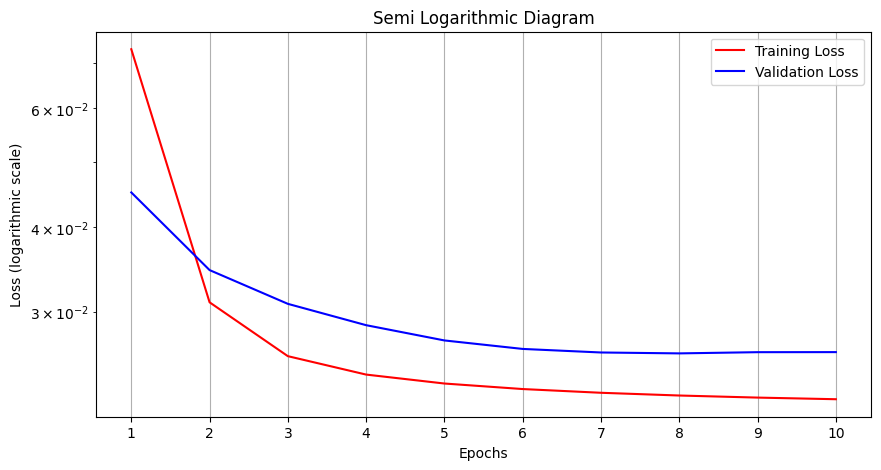

In [19]:
x_values = range(1, len(history_early_stopping.history['loss']) + 1)

fig = plt.figure(figsize=(10, 5))

plt.semilogy(x_values, history_early_stopping.history['loss'], label='Training Loss', color='r')
plt.semilogy(x_values, history_early_stopping.history['val_loss'], label='Validation Loss', color='b')

plt.xlabel('Epochs')
plt.ylabel('Loss (logarithmic scale)')
plt.title('Semi Logarithmic Diagram')

plt.legend()
plt.grid()
plt.xticks(x_values)
plt.show()

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [21]:
#Root Mean Squared Error
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train)) 
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test)) 

#Mean Absolute Error
mae_train = mean_absolute_error(y_train, y_pred_train) 
mae_test = mean_absolute_error(y_test, y_pred_test) 

In [22]:
print("\033[1mRoot Mean Squared Error\033[0m")
print(f"Training set: RMSE ={rmse_train: .3f}")
print(f"Test set: RMSE ={rmse_test: .3f}")

print("\n\033[1mMean Absolute Error\033[0m")
print(f"Training set: MAE ={mae_train: .3f}")
print(f"Test set: MAE ={mae_test: .3f}")

Root Mean Squared Error
Training set: RMSE = 0.151
Test set: RMSE = 0.095

Mean Absolute Error
Training set: MAE = 0.114
Test set: MAE = 0.077


**Conclusion** \
As we can observe from the plot, both training and validation loss decrease significantly(a little smoother the validation loss) in the beginning and then stabilize, indicating that our model is learning effectively without signs of overfitting. Since the training and validation loss curves remain close to each other throughout training, it suggests that our model generalizes well to new data. Early stopping also helped to prevent overfitting by stopping training porcess once our model's performance stopped improving. \
Additionally, both metrics, RMSE and MAE, are low and in our case are lower on the test set compared to the training set, which indicates that our model generalizes well to unseen data. The low values of RMSE and MAE on the test set confirm our model's good generalization. \
Overall, our Multilayer Perceprton Model has been succesfully trained, generalizes well and achieves high performance with low RMSE and MAE on both test and training sets, indicating effective learning without overfitting.

**6. Forecast Visualization and Discussion**

(we have already computed the prediction based on the test set in question 5)

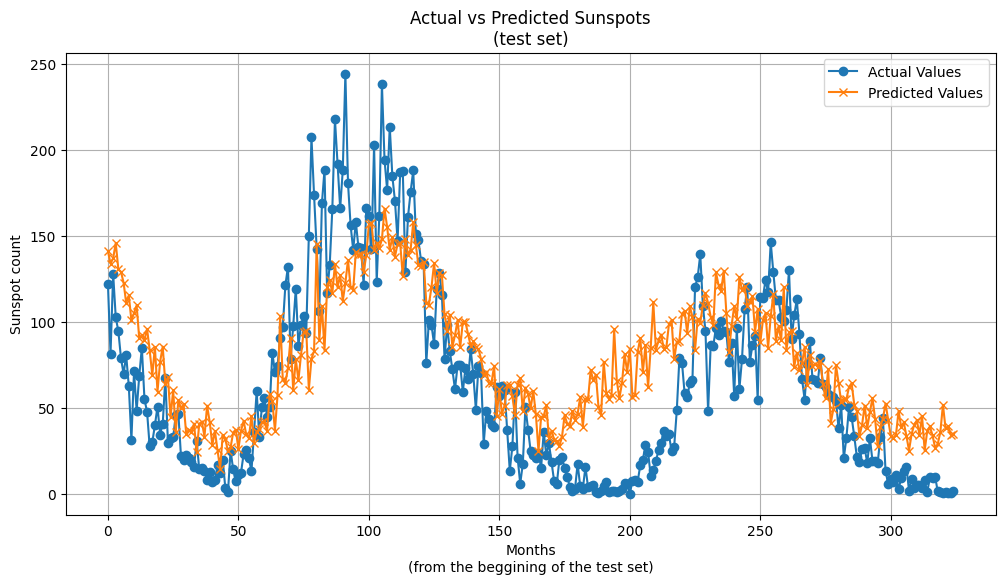

In [43]:
#We will apply the inverse transformation to revert the test data(y_test) and the predicted values(y_pred_test) back to their original scale
y_test_recovered = min_max_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_test_recovered = min_max_scaler.inverse_transform(y_pred_test.reshape(-1, 1))

plt.figure(figsize=(12, 6))
plt.plot(y_test_recovered, label="Actual Values", marker='o')
plt.plot(y_pred_test_recovered, label="Predicted Values", marker='x')

#plt.title(f"Forecasting {forecast_horizon} steps ahead\n(test set)")
plt.title("Actual vs Predicted Sunspots\n(test set)")
plt.xlabel("Months\n(from the beggining of the test set)")
plt.ylabel("Sunspot count")

plt.legend()
plt.grid()
plt.show()

**Conclusion** \
The diagram compares the actual sunspot values with the predictions from our MLP model over a 325 months period. The model performs well in capturing the overall trend and periodic changes, with the predicted values following the actuals in terms of timing and shape. \
However, there are noticeable differences in intensity, as the model tends to underestimate the higher peaks and overestimate some of the lower points compared to the actual values. \
Additionally, as we can observe, after approximately 150 months, the predictions become less accurate and show a clear deviation from the actual values, indicating that the model struggles with long-term forecasting horizons.

**7. GRU Model and Performance Comparison**

In [44]:
#The data for a GRU model should be in 3D format ((n_samples, timesteps, n_features)
X_train_gru = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_gru = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [45]:
gru_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window_size, 1)),
    tf.keras.layers.GRU(50, activation='selu', 
                          kernel_initializer='lecun_normal', return_sequences=True),
    tf.keras.layers.GRU(25, activation='selu', 
                          kernel_initializer='lecun_normal'),
    tf.keras.layers.Dense(forecast_horizon)
])

In [46]:
gru_model.compile(loss="mse", optimizer=tf.keras.optimizers.AdamW(),
                  metrics=["mae"])

In [47]:
early_stopping_gpu = tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                      patience=2, 
                                                      restore_best_weights=True,
                                                      min_delta=0.0005)

start_time = time.time()

history_early_stopping_gru = gru_model.fit(X_train_gru, y_train,
                                           epochs=30, batch_size=32,
                                           validation_split=0.1,
                                           callbacks=[early_stopping_gpu])

train_time_gru = time.time() - start_time

Epoch 1/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0564 - mae: 0.1783 - val_loss: 0.0397 - val_mae: 0.1551
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0269 - mae: 0.1300 - val_loss: 0.0341 - val_mae: 0.1385
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0250 - mae: 0.1231 - val_loss: 0.0286 - val_mae: 0.1234
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0234 - mae: 0.1170 - val_loss: 0.0246 - val_mae: 0.1125
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0225 - mae: 0.1135 - val_loss: 0.0236 - val_mae: 0.1099
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0222 - mae: 0.1124 - val_loss: 0.0234 - val_mae: 0.1098
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0220 - mae: 0.1118 - val_loss: 0.0236 - val_mae: 0.1103


In [48]:
print(f"Training time(GRU): {train_time_gru:.2f} seconds")

Training time(GRU): 15.62 seconds


In [49]:
y_pred_test_gru = gru_model.predict(X_test_gru)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


In [50]:
#Room Mean Squared Error
rmse_test_gru = np.sqrt(mean_squared_error(y_test, y_pred_test_gru))
#Mean Absolute Error
mae_test_gru = mean_absolute_error(y_test, y_pred_test_gru)

In [51]:
print("\033[1mRoot Mean Squared Error\033[0m")
print(f"Test set: RMSE(GRU) ={rmse_test_gru: .3f}")

print("\n\033[1mMean Absolute Error\033[0m")
print(f"Test set: MAE(GRU) ={mae_test_gru: .3f}")

Root Mean Squared Error
Test set: RMSE(GRU) = 0.094

Mean Absolute Error
Test set: MAE(GRU) = 0.074


In [52]:
#Comparing of performance metrics between MLP and GLU models
print("\033[1mPerformance Comparison Between GRU and MLP Models \n(test set)\033[0m")
print(f"RMSE(GRU) ={rmse_test_gru: .3f}")
print(f"RMSE(MLP) ={rmse_test: .3f}")
print(f"MAE(GRU) ={mae_test_gru: .3f}")
print(f"MAE(MLP) ={mae_test: .3f}")

Performance Comparison Between GRU and MLP Models 
(test set)
RMSE(GRU) = 0.094
RMSE(MLP) = 0.095
MAE(GRU) = 0.074
MAE(MLP) = 0.077


**Conclusion** \
As we observe the performance of both metrics(RMSE and MAE) for the two models, we can see that they perform quite similarly. However, the GRU model achieves slightly better accuracy, with lower RMSE and MAE, indicating that it is more effective for time-series forecasting. However the MLP model was trained much faster than the GRU model. Overall the GRU model provides better results but takes longer to train, while MLP is faster but with slighly lower accuracy.